# EMIPredict_AI

# Github Repository link 

https://github.com/vanshikakotgirwar02/EMIPredict-AI.git

In [2]:
# imprt libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the EMI prediction dataset

df = pd.read_csv("../data/emi_prediction_dataset.csv")

# Display the first 5 rows
df.head()

C:\Users\kotgi\AppData\Local\Temp\ipykernel_6092\2740864284.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/emi_prediction_dataset.csv")


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [5]:
# Check the number of rows and columns in the dataset

df.shape


(404800, 27)

In [5]:
# Display all column names in the dataset

df.columns.tolist()

['age',
 'gender',
 'marital_status',
 'education',
 'monthly_salary',
 'employment_type',
 'years_of_employment',
 'company_type',
 'house_type',
 'monthly_rent',
 'family_size',
 'dependents',
 'school_fees',
 'college_fees',
 'travel_expenses',
 'groceries_utilities',
 'other_monthly_expenses',
 'existing_loans',
 'current_emi_amount',
 'credit_score',
 'bank_balance',
 'emergency_fund',
 'emi_scenario',
 'requested_amount',
 'requested_tenure',
 'emi_eligibility',
 'max_monthly_emi']

In [6]:
# Check the data type of every column

df.dtypes

age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance               object
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object

In [7]:
# Display a summary of the dataset including data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [8]:
# Count missing values in every column

missing_values = df.isnull().sum()

missing_values

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [9]:
# Calculate the percentage of missing values in each column

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

monthly_rent              0.599308
bank_balance              0.599308
credit_score              0.597826
education                 0.593874
emergency_fund            0.580781
marital_status            0.000000
monthly_salary            0.000000
years_of_employment       0.000000
gender                    0.000000
employment_type           0.000000
age                       0.000000
family_size               0.000000
house_type                0.000000
company_type              0.000000
dependents                0.000000
groceries_utilities       0.000000
school_fees               0.000000
college_fees              0.000000
travel_expenses           0.000000
current_emi_amount        0.000000
existing_loans            0.000000
other_monthly_expenses    0.000000
emi_scenario              0.000000
requested_amount          0.000000
requested_tenure          0.000000
emi_eligibility           0.000000
max_monthly_emi           0.000000
dtype: float64

In [10]:
# Count the number of completely duplicated rows

duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(0)

In [11]:
# Generate descriptive statistics for numerical columns

df.describe()

,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,404800.000000,402374.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,402380.000000,402449.000000,4.048000e+05,404800.000000,404800.000000
mean,5.364079,5828.446490,2.940425,1.940425,4624.575593,4066.253706,5687.497777,12804.999506,7119.309783,4543.407609,700.856223,96769.051731,3.708554e+05,29.126677,6763.602156
std,6.079135,8648.604639,1.075199,1.075199,5061.074401,7319.344289,3392.671132,6993.853745,4510.447300,7034.901139,88.435548,81373.053976,3.451945e+05,18.100854,7741.263317
min,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,0.000000,0.000000,1400.000000,1.000000e+04,3.000000,500.000000
25%,1.200000,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,0.000000,654.000000,38400.000000,1.240000e+05,15.000000,500.000000
50%,3.200000,0.000000,3.000000,2.000000,3000.000000,0.000000,4900.000000,11400.000000,6000.000000,0.000000,701.000000,74000.000000,2.360000e+05,25.000000,4211.200000
75%,7.200000,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7400.000000,16400.000000,9300.000000,8000.000000,748.000000,130600.000000,4.940000e+05,40.000000,9792.000000
max,36.000000,80000.000000,5.000000,4.000000,15000.000000,25000.000000,30300.000000,71200.000000,42900.000000,56300.000000,1200.000000,891500.000000,1.500000e+06,84.000000,91040.400000


In [12]:
# Display unique values for important categorical columns

categorical_columns = [
    'gender',
    'marital_status',
    'education',
    'employment_type',
    'company_type',
    'house_type',
    'existing_loans',
    'emi_scenario',
    'emi_eligibility'
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


gender:
['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']

marital_status:
['Married' 'Single']

education:
['Professional' 'Graduate' 'High School' 'Post Graduate' nan]

employment_type:
['Private' 'Government' 'Self-employed']

company_type:
['Mid-size' 'MNC' 'Startup' 'Large Indian' 'Small']

house_type:
['Rented' 'Family' 'Own']

existing_loans:
['Yes' 'No']

emi_scenario:
['Personal Loan EMI' 'E-commerce Shopping EMI' 'Education EMI'
 'Vehicle EMI' 'Home Appliances EMI']

emi_eligibility:
['Not_Eligible' 'Eligible' 'High_Risk']


In [13]:
# Display the number of records in each category

for column in categorical_columns:
    print(f"\n{column} value counts:")
    print(df[column].value_counts())


gender value counts:
gender
Male      237427
Female    158351
MALE        1865
M           1843
male        1815
F           1171
female      1165
FEMALE      1163
Name: count, dtype: int64

marital_status value counts:
marital_status
Married    307837
Single      96963
Name: count, dtype: int64

education value counts:
education
Graduate         181015
Post Graduate    100314
High School       60732
Professional      60335
Name: count, dtype: int64

employment_type value counts:
employment_type
Private          283099
Government        81167
Self-employed     40534
Name: count, dtype: int64

company_type value counts:
company_type
Large Indian    121139
MNC             101409
Mid-size        101301
Startup          60706
Small            20245
Name: count, dtype: int64

house_type value counts:
house_type
Rented    161601
Own       142307
Family    100892
Name: count, dtype: int64

existing_loans value counts:
existing_loans
No     243227
Yes    161573
Name: count, dtype: int64

emi_

In [14]:
# Check the distribution of the EMI eligibility target

eligibility_counts = df['emi_eligibility'].value_counts()

eligibility_counts

emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

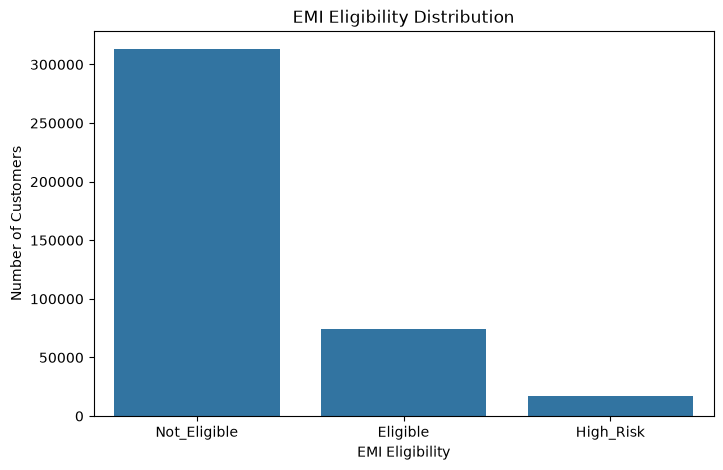

In [15]:
# Visualize the distribution of EMI eligibility

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='emi_eligibility')

plt.title('EMI Eligibility Distribution')
plt.xlabel('EMI Eligibility')
plt.ylabel('Number of Customers')

plt.show()

In [16]:
# Generate descriptive statistics for the maximum monthly EMI target

df['max_monthly_emi'].describe()

count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64

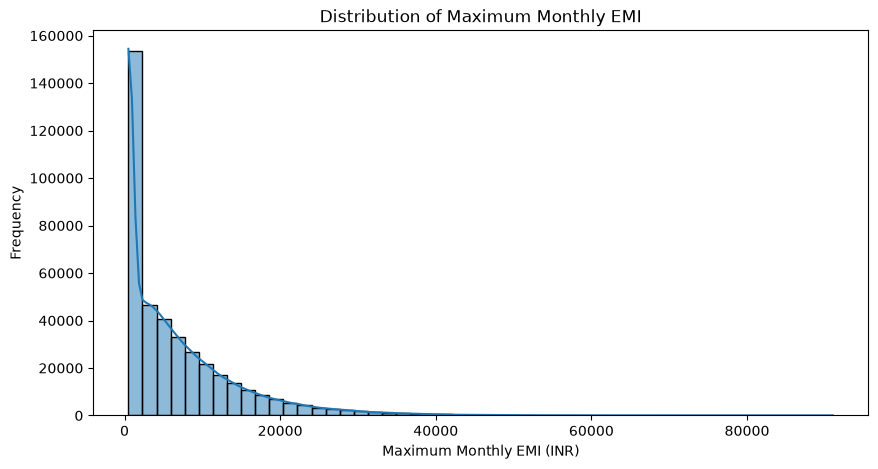

In [17]:
# Visualize the distribution of maximum monthly EMI

plt.figure(figsize=(10, 5))

sns.histplot(df['max_monthly_emi'], bins=50, kde=True)

plt.title('Distribution of Maximum Monthly EMI')
plt.xlabel('Maximum Monthly EMI (INR)')
plt.ylabel('Frequency')

plt.show()

In [18]:
# Inspect the unique values present in the age column

df['age'].unique()[:50]

array([38.0, 58.0, 48.0, 32.0, 27.0, 47.0, 37.0, 31.0, 59.0, 49.0, 33.0,
       26.0, 39.0, 57.0, 28.0, '58', '38', '48', '32', '27', '37', '48.0',
       '33', '38.0', '49', '27.0', '31', '39', '47', '59', '32.0', '58.0',
       '57', '26', '28', '58.0.0', '39.0', '26.0', '37.0', '38.0.0',
       '32.0.0'], dtype=object)

In [19]:
# Check which data types are present in the age column

df['age'].map(type).value_counts()

age
<class 'float'>    306496
<class 'str'>       98304
Name: count, dtype: int64

In [20]:
# Display age values that cannot be converted to numeric values

age_numeric = pd.to_numeric(df['age'], errors='coerce')

invalid_age = df.loc[age_numeric.isna(), 'age']

invalid_age.value_counts().head(20)

age
58.0.0    1
38.0.0    1
32.0.0    1
Name: count, dtype: int64

In [6]:
# Convert the age column to numeric values

df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Check the new data type
df['age'].dtype

dtype('float64')

In [7]:
# Check whether any age values became missing after conversion

df['age'].isnull().sum()

np.int64(3)

In [8]:
# Check the minimum and maximum age after conversion

print("Minimum age:", df['age'].min())
print("Maximum age:", df['age'].max())

Minimum age: 26.0
Maximum age: 59.0


In [9]:
# Identify all numerical columns in the dataset

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

numerical_columns

['age',
 'years_of_employment',
 'monthly_rent',
 'family_size',
 'dependents',
 'school_fees',
 'college_fees',
 'travel_expenses',
 'groceries_utilities',
 'other_monthly_expenses',
 'current_emi_amount',
 'credit_score',
 'emergency_fund',
 'requested_amount',
 'requested_tenure',
 'max_monthly_emi']

In [10]:
# Check the minimum and maximum values of all numerical columns

numeric_summary = df[numerical_columns].agg(['min', 'max']).T

numeric_summary

,min,max
age,26.0,59.0
years_of_employment,0.5,36.0
monthly_rent,0.0,80000.0
family_size,1.0,5.0
dependents,0.0,4.0
school_fees,0.0,15000.0
college_fees,0.0,25000.0
travel_expenses,600.0,30300.0
groceries_utilities,1800.0,71200.0
other_monthly_expenses,600.0,42900.0


In [11]:
# Check unique values for selected numerical columns

columns_to_check = [
    'age',
    'family_size',
    'dependents',
    'years_of_employment',
    'credit_score',
    'requested_tenure'
]

for column in columns_to_check:
    print(f"\n{column}:")
    print("Unique values:", df[column].nunique())
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())


age:
Unique values: 15
Minimum: 26.0
Maximum: 59.0

family_size:
Unique values: 5
Minimum: 1
Maximum: 5

dependents:
Unique values: 5
Minimum: 0
Maximum: 4

years_of_employment:
Unique values: 356
Minimum: 0.5
Maximum: 36.0

credit_score:
Unique values: 427
Minimum: 0.0
Maximum: 1200.0

requested_tenure:
Unique values: 82
Minimum: 3
Maximum: 84


In [12]:
# Count negative values in numerical columns

negative_values = (df[numerical_columns] < 0).sum()

negative_values[negative_values > 0]

Series([], dtype: int64)

In [13]:
# Check missing values after cleaning the age column

missing_after_age_cleaning = df.isnull().sum()

missing_after_age_cleaning[missing_after_age_cleaning > 0]

age                  3
education         2404
monthly_rent      2426
credit_score      2420
bank_balance      2426
emergency_fund    2351
dtype: int64

In [14]:
# Calculate the total number of duplicate records

duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


In [15]:
# Calculate the percentage of missing values in each column

missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

# Display only columns containing missing values
missing_summary[missing_summary['Missing_Count'] > 0]

,Missing_Count,Missing_Percentage
age,3,0.000741
education,2404,0.593874
monthly_rent,2426,0.599308
credit_score,2420,0.597826
bank_balance,2426,0.599308
emergency_fund,2351,0.580781


In [18]:
# Check missing values in categorical columns

categorical_columns = [
    'gender',
    'marital_status',
    'education',
    'employment_type',
    'company_type',
    'house_type',
    'existing_loans',
    'emi_scenario',
    'emi_eligibility'
]

categorical_missing = df[categorical_columns].isnull().sum()

categorical_missing[categorical_missing > 0]

education    2404
dtype: int64

In [19]:
# Display the most frequent value in each categorical column

for column in categorical_columns:
    print(f"{column}: {df[column].mode()[0]}")

gender: Male
marital_status: Married
education: Graduate
employment_type: Private
company_type: Large Indian
house_type: Rented
existing_loans: No
emi_scenario: Home Appliances EMI
emi_eligibility: Not_Eligible


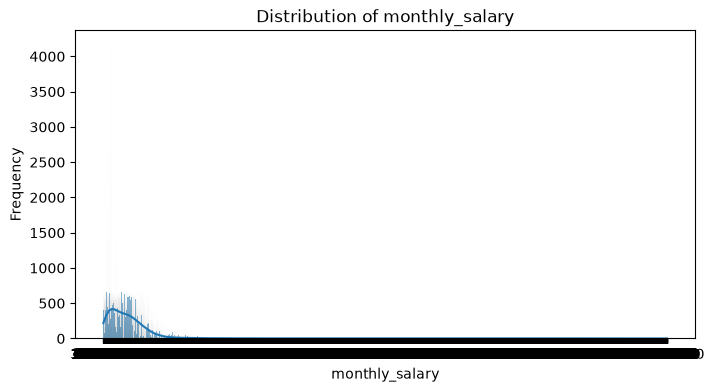

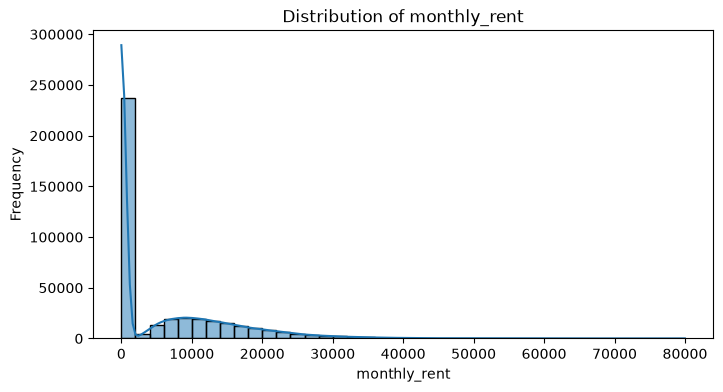

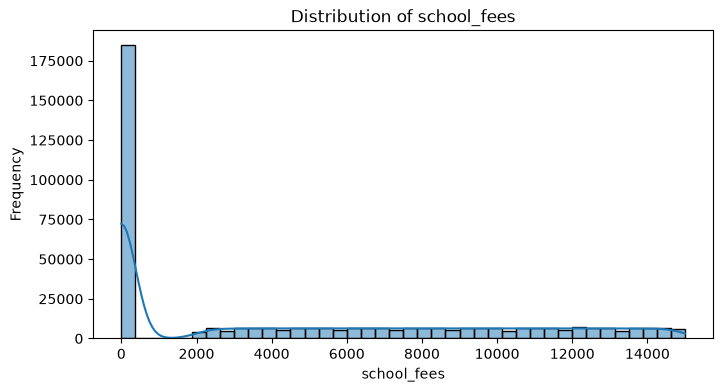

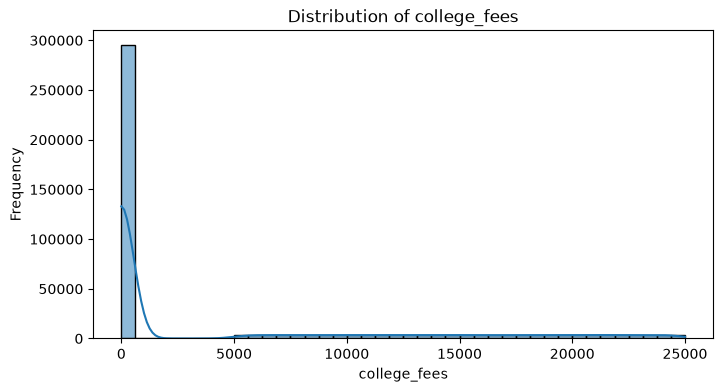

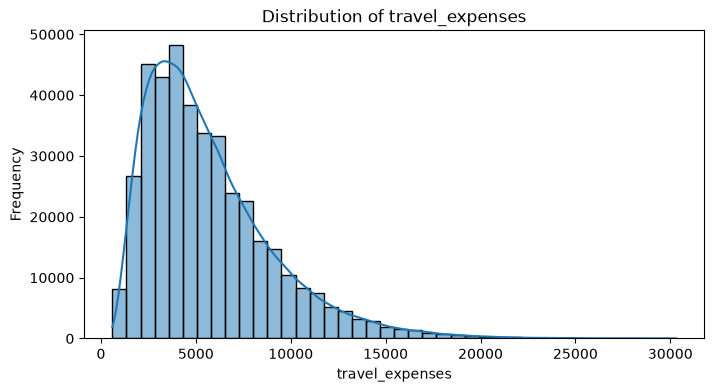

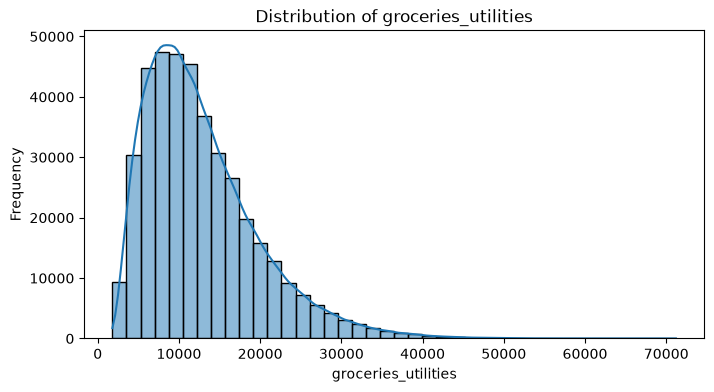

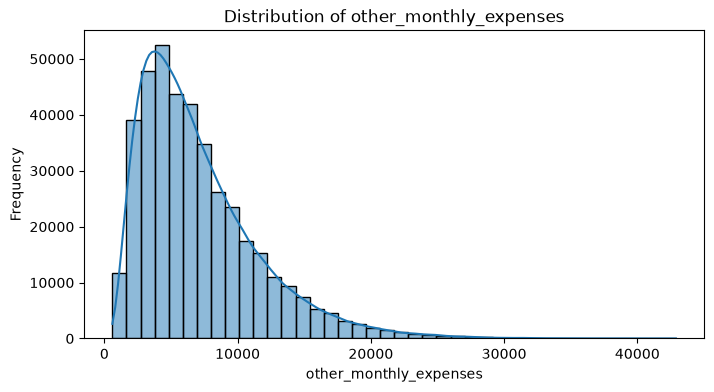

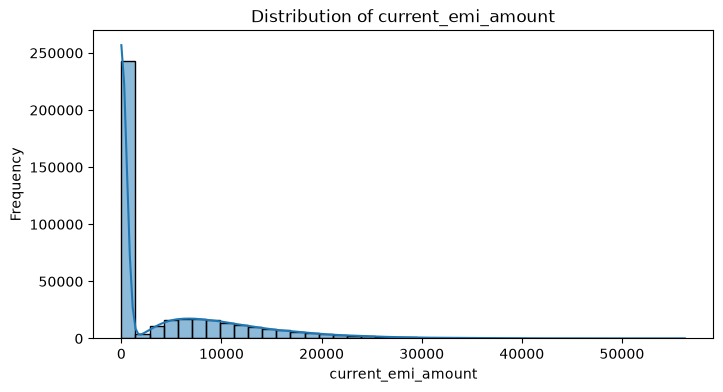

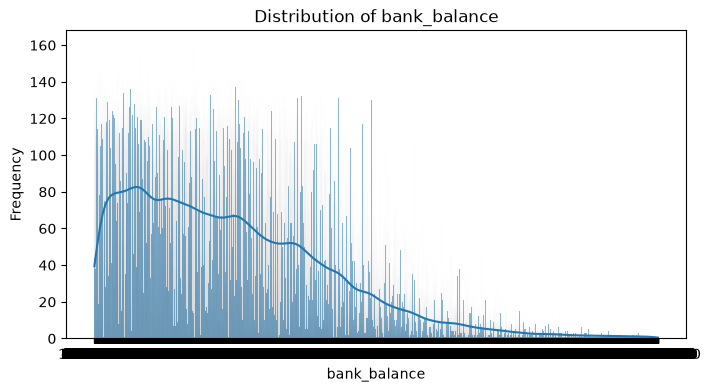

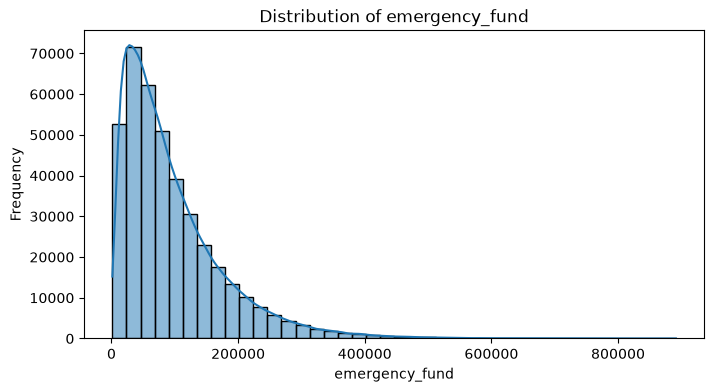

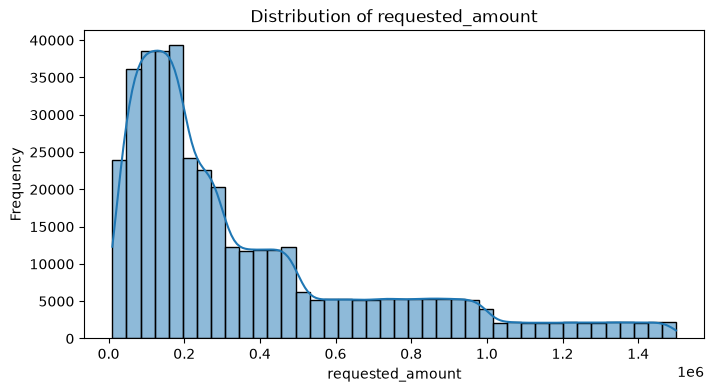

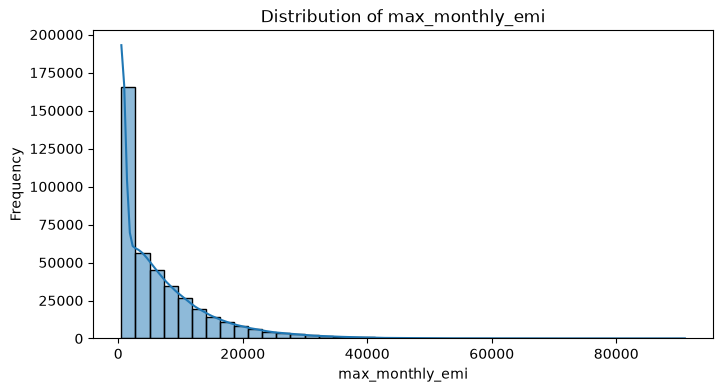

In [20]:
# Visualize the distributions of important financial variables

financial_columns = [
    'monthly_salary',
    'monthly_rent',
    'school_fees',
    'college_fees',
    'travel_expenses',
    'groceries_utilities',
    'other_monthly_expenses',
    'current_emi_amount',
    'bank_balance',
    'emergency_fund',
    'requested_amount',
    'max_monthly_emi'
]

for column in financial_columns:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(df[column], bins=40, kde=True)
    
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    
    plt.show()

In [21]:
# Detect potential outliers using the Interquartile Range (IQR) method

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    
    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outliers,
        'Outlier_Percentage': (outliers / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    by='Outlier_Count',
    ascending=False
)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
6,college_fees,0.0,6500.0,6500.0,-9750.0,16250.0,48000,11.857708
13,requested_amount,124000.0,494000.0,370000.0,-431000.0,1049000.0,25883,6.394022
1,years_of_employment,1.2,7.2,6.0,-7.8,16.2,22891,5.654891
12,emergency_fund,38400.0,130600.0,92200.0,-99900.0,268900.0,17542,4.333498
10,current_emi_amount,0.0,8000.0,8000.0,-12000.0,20000.0,17351,4.286314
15,max_monthly_emi,500.0,9792.0,9292.0,-13438.0,23730.0,17268,4.265810
9,other_monthly_expenses,3800.0,9300.0,5500.0,-4450.0,17550.0,13518,3.339427
2,monthly_rent,0.0,10600.0,10600.0,-15900.0,26500.0,12720,3.142292
7,travel_expenses,3200.0,7400.0,4200.0,-3100.0,13700.0,12465,3.079298
8,groceries_utilities,7700.0,16400.0,8700.0,-5350.0,29450.0,11774,2.908597


In [22]:
# Display columns that contain potential outliers

outlier_summary[
    outlier_summary['Outlier_Count'] > 0
][[
    'Column',
    'Outlier_Count',
    'Outlier_Percentage'
]]

,Column,Outlier_Count,Outlier_Percentage
1,years_of_employment,22891,5.654891
2,monthly_rent,12720,3.142292
6,college_fees,48000,11.857708
7,travel_expenses,12465,3.079298
8,groceries_utilities,11774,2.908597
9,other_monthly_expenses,13518,3.339427
10,current_emi_amount,17351,4.286314
11,credit_score,5840,1.442688
12,emergency_fund,17542,4.333498
13,requested_amount,25883,6.394022


In [24]:
# Calculate correlations between numerical variables

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,age,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
age,1.000000,0.479588,0.000126,0.209040,0.209040,0.061767,0.037248,-0.001517,-0.001804,-0.000568,-0.001576,0.063956,-0.001975,0.001329,0.000328,-0.000848
years_of_employment,0.479588,1.000000,0.000386,0.101765,0.101765,0.030581,0.018484,-0.001425,-0.000419,-0.000536,-0.000083,0.116542,-0.000987,0.000900,-0.000595,0.028887
monthly_rent,0.000126,0.000386,1.000000,-0.002316,-0.002316,-0.003623,0.000867,0.273728,0.297642,0.254352,0.101954,0.033349,0.189613,-0.000967,0.000777,-0.170097
family_size,0.209040,0.101765,-0.002316,1.000000,1.000000,0.175168,0.107256,-0.001318,-0.001649,-0.000918,-0.001322,0.020607,-0.002836,0.000633,-0.002360,-0.062266
dependents,0.209040,0.101765,-0.002316,1.000000,1.000000,0.175168,0.107256,-0.001318,-0.001649,-0.000918,-0.001322,0.020607,-0.002836,0.000633,-0.002360,-0.062266
school_fees,0.061767,0.030581,-0.003623,0.175168,0.175168,1.000000,0.054541,0.000548,-0.000166,0.000370,-0.001478,0.006327,-0.002020,0.001422,0.000103,-0.215234
college_fees,0.037248,0.018484,0.000867,0.107256,0.107256,0.054541,1.000000,-0.001914,-0.002538,-0.000303,0.000679,0.002924,-0.002052,0.003810,-0.001239,-0.258842
travel_expenses,-0.001517,-0.001425,0.273728,-0.001318,-0.001318,0.000548,-0.001914,1.000000,0.772067,0.666282,0.270107,0.090412,0.501080,-0.000522,-0.000698,0.440948
groceries_utilities,-0.001804,-0.000419,0.297642,-0.001649,-0.001649,-0.000166,-0.002538,0.772067,1.000000,0.726931,0.295707,0.099212,0.547499,0.000400,-0.000246,0.484695
other_monthly_expenses,-0.000568,-0.000536,0.254352,-0.000918,-0.000918,0.000370,-0.000303,0.666282,0.726931,1.000000,0.254730,0.085177,0.472869,-0.001905,-0.001177,0.382055


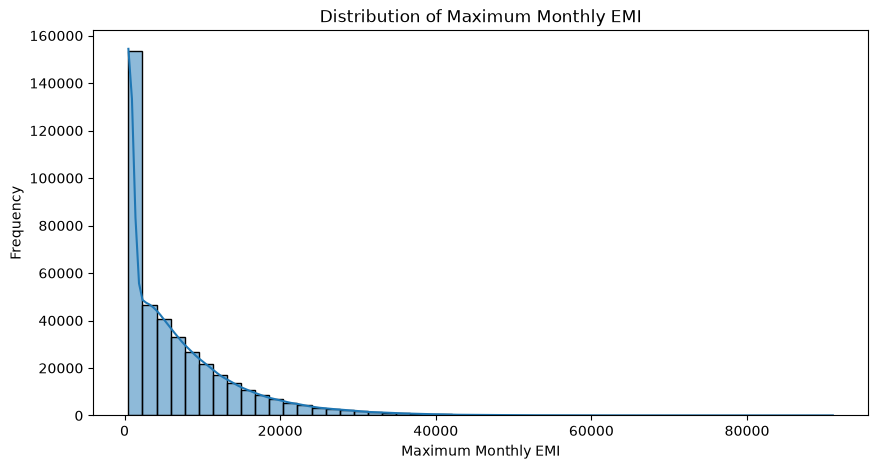

In [25]:
# Plot the distribution of the target variable

plt.figure(figsize=(10, 5))

sns.histplot(
    df['max_monthly_emi'],
    bins=50,
    kde=True
)

plt.title('Distribution of Maximum Monthly EMI')
plt.xlabel('Maximum Monthly EMI')
plt.ylabel('Frequency')

plt.show()

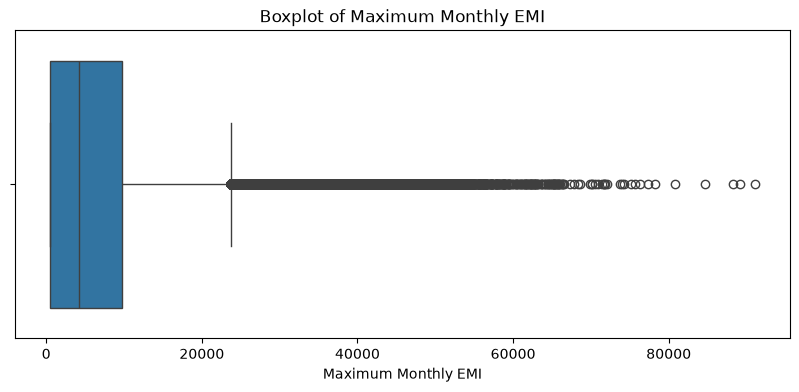

In [28]:
# Check the distribution and potential extreme values of the target variable

plt.figure(figsize=(10, 4))

sns.boxplot(x=df['max_monthly_emi'])

plt.title('Boxplot of Maximum Monthly EMI')
plt.xlabel('Maximum Monthly EMI')

plt.show()

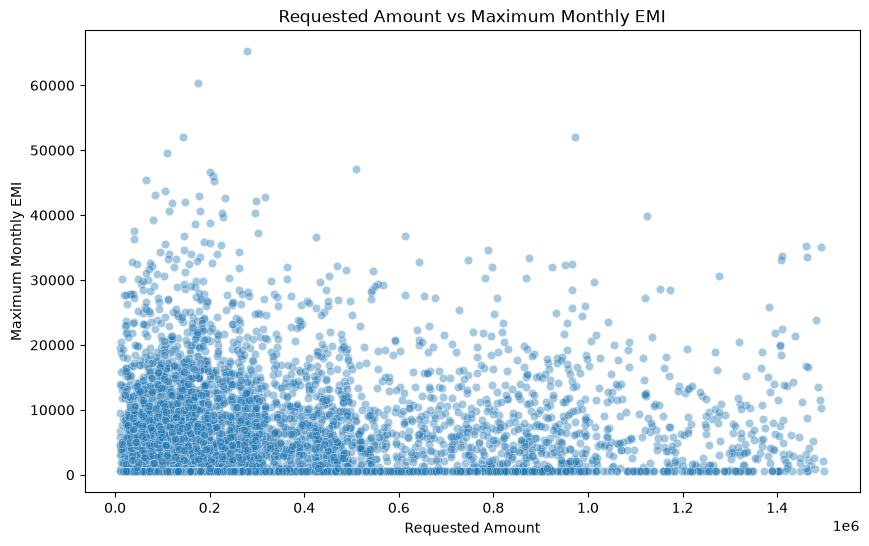

In [29]:
# Visualize the relationship between requested loan amount and maximum monthly EMI

sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x='requested_amount',
    y='max_monthly_emi',
    alpha=0.4
)

plt.title('Requested Amount vs Maximum Monthly EMI')
plt.xlabel('Requested Amount')
plt.ylabel('Maximum Monthly EMI')

plt.show()

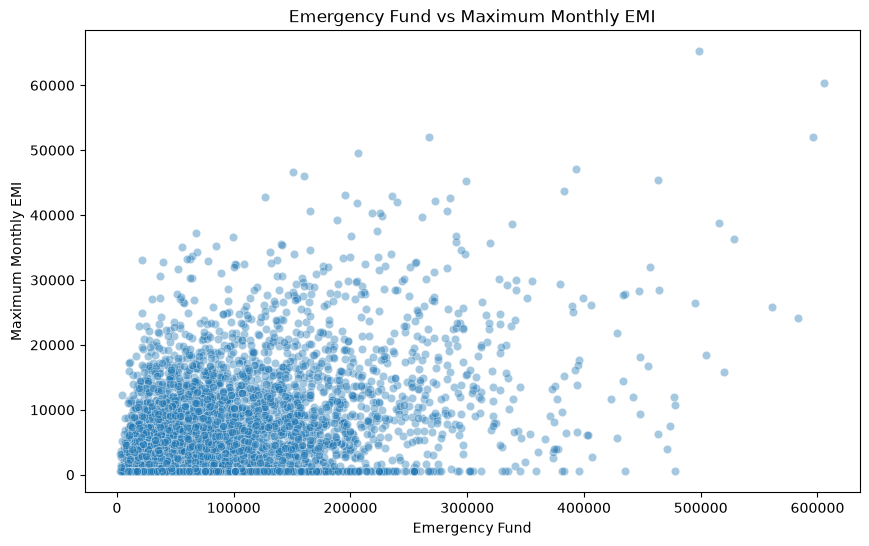

In [30]:
# Visualize the relationship between emergency fund and maximum monthly EMI

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x='emergency_fund',
    y='max_monthly_emi',
    alpha=0.4
)

plt.title('Emergency Fund vs Maximum Monthly EMI')
plt.xlabel('Emergency Fund')
plt.ylabel('Maximum Monthly EMI')

plt.show()

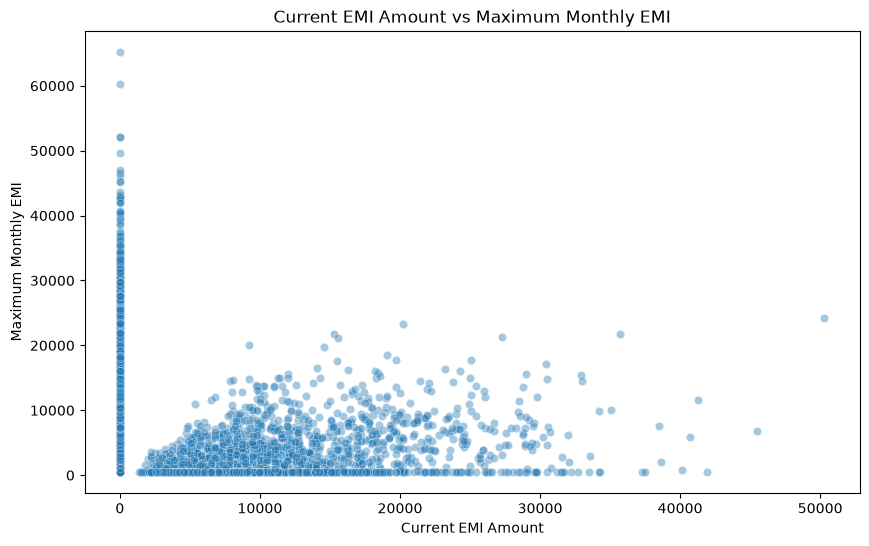

In [31]:
# Visualize the relationship between current EMI and maximum monthly EMI

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x='current_emi_amount',
    y='max_monthly_emi',
    alpha=0.4
)

plt.title('Current EMI Amount vs Maximum Monthly EMI')
plt.xlabel('Current EMI Amount')
plt.ylabel('Maximum Monthly EMI')

plt.show()

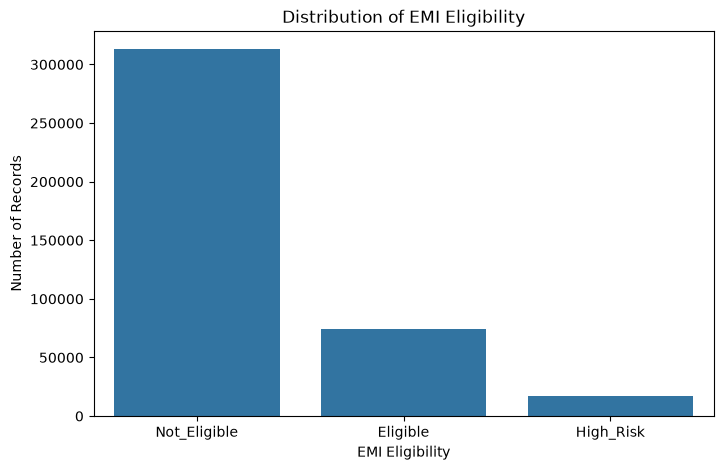

In [32]:
# Check the distribution of EMI eligibility categories

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='emi_eligibility'
)

plt.title('Distribution of EMI Eligibility')
plt.xlabel('EMI Eligibility')
plt.ylabel('Number of Records')

plt.show()

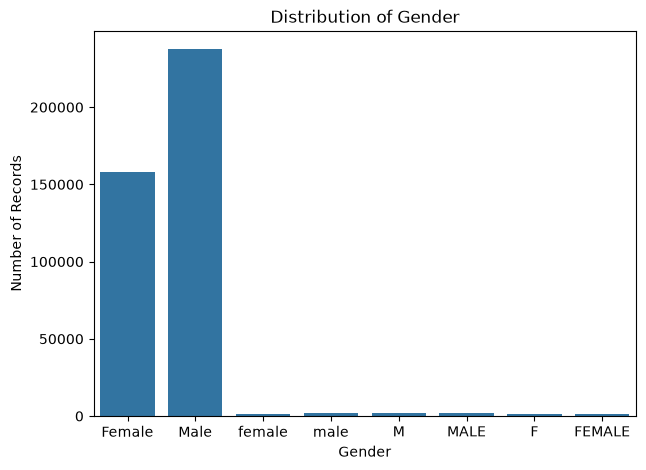

In [33]:
# Check the distribution of customers by gender

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='gender'
)

plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Records')

plt.show()

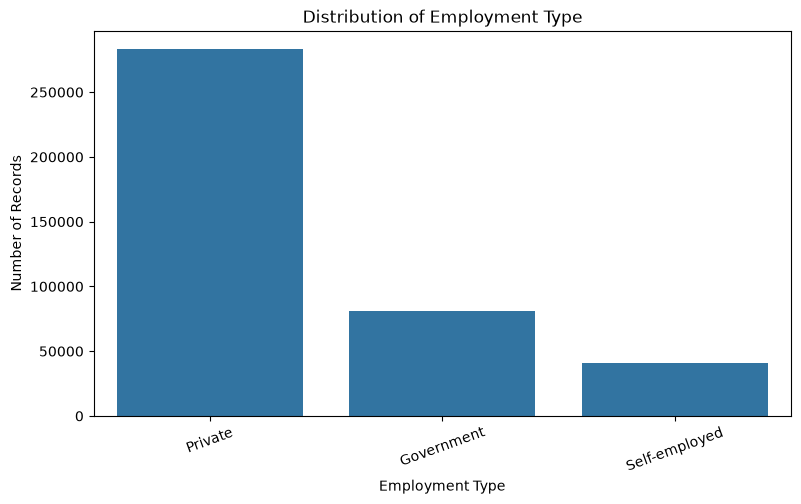

In [34]:
# Check the distribution of employment types

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='employment_type'
)

plt.title('Distribution of Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Number of Records')

plt.xticks(rotation=20)

plt.show()

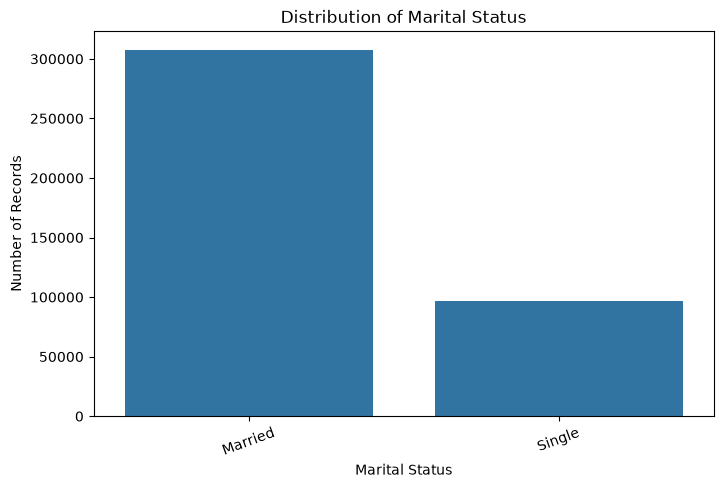

In [35]:
# Check the distribution of marital status

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='marital_status'
)

plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Records')

plt.xticks(rotation=20)

plt.show()

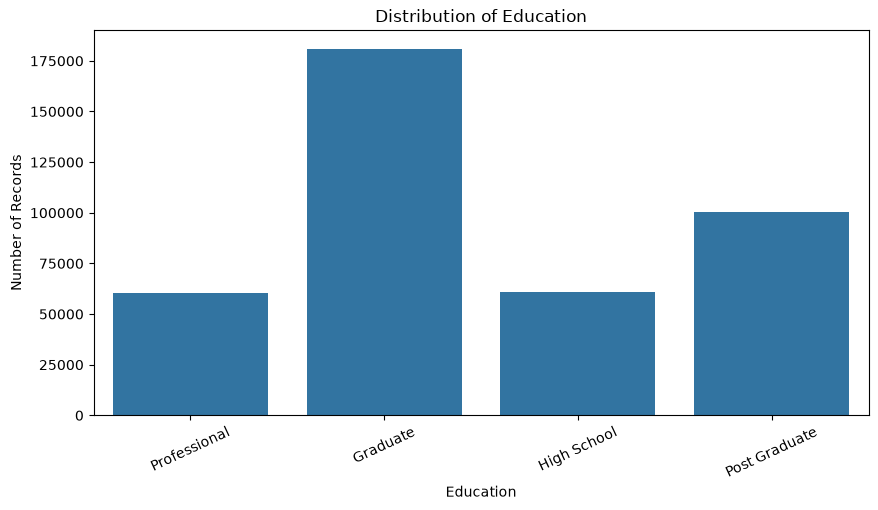

In [36]:
# Check the distribution of education levels

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='education'
)

plt.title('Distribution of Education')
plt.xlabel('Education')
plt.ylabel('Number of Records')

plt.xticks(rotation=25)

plt.show()

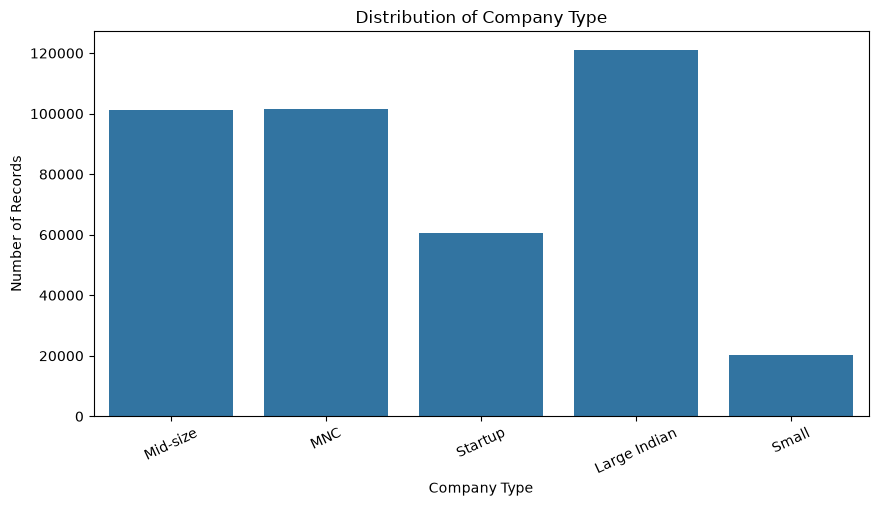

In [37]:
# Check the distribution of company types

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='company_type'
)

plt.title('Distribution of Company Type')
plt.xlabel('Company Type')
plt.ylabel('Number of Records')

plt.xticks(rotation=25)

plt.show()

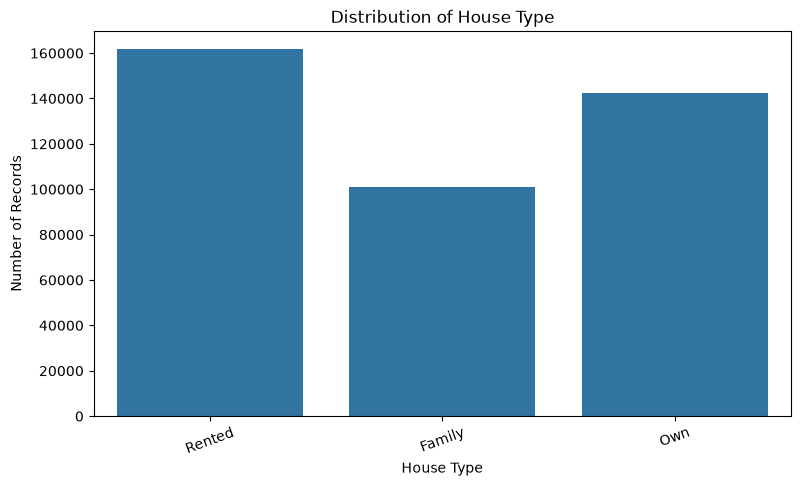

In [38]:
# Check the distribution of house types

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='house_type'
)

plt.title('Distribution of House Type')
plt.xlabel('House Type')
plt.ylabel('Number of Records')

plt.xticks(rotation=20)

plt.show()

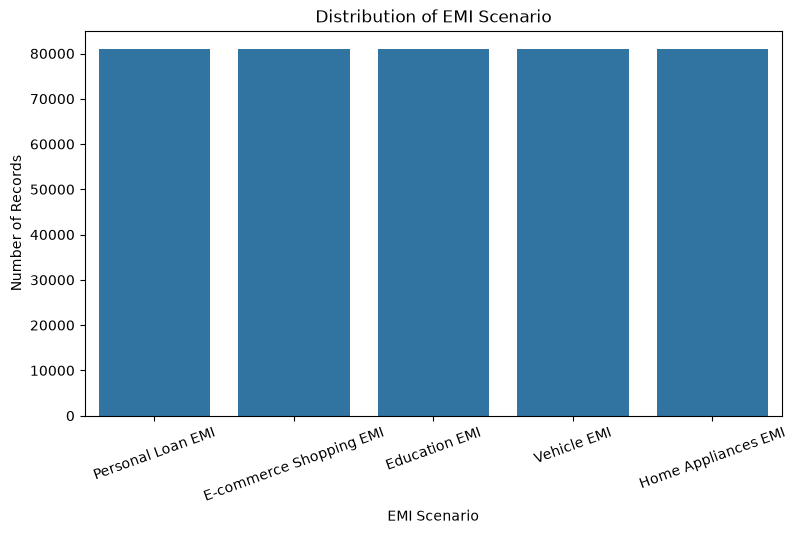

In [39]:
# Check the distribution of EMI scenarios

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='emi_scenario'
)

plt.title('Distribution of EMI Scenario')
plt.xlabel('EMI Scenario')
plt.ylabel('Number of Records')

plt.xticks(rotation=20)

plt.show()

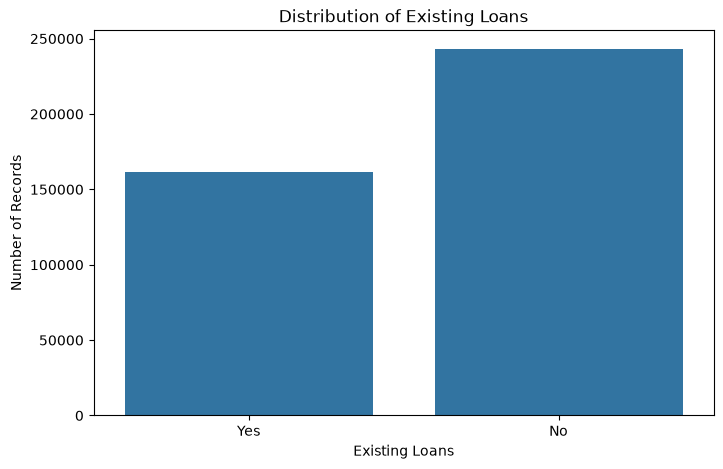

In [40]:
# Check the distribution of existing loans

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='existing_loans'
)

plt.title('Distribution of Existing Loans')
plt.xlabel('Existing Loans')
plt.ylabel('Number of Records')

plt.show()

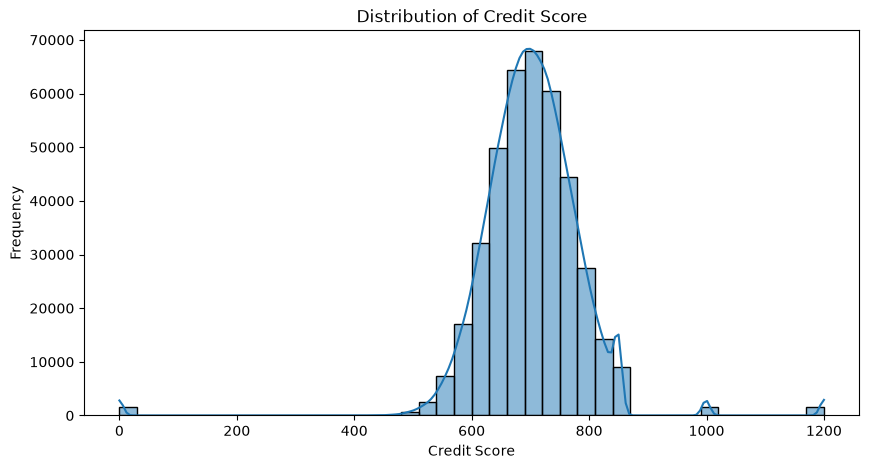

In [41]:
# Visualize the distribution of credit scores

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='credit_score',
    bins=40,
    kde=True
)

plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')

plt.show()

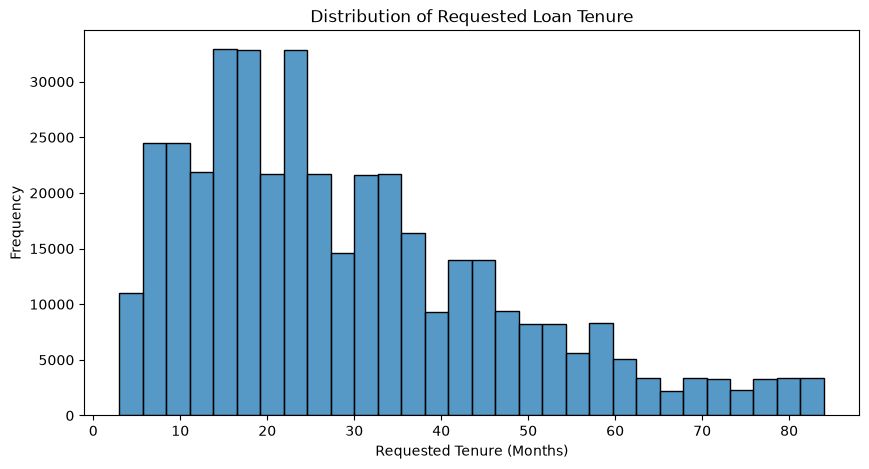

In [42]:
# Visualize the distribution of requested loan tenure

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='requested_tenure',
    bins=30
)

plt.title('Distribution of Requested Loan Tenure')
plt.xlabel('Requested Tenure (Months)')
plt.ylabel('Frequency')

plt.show()

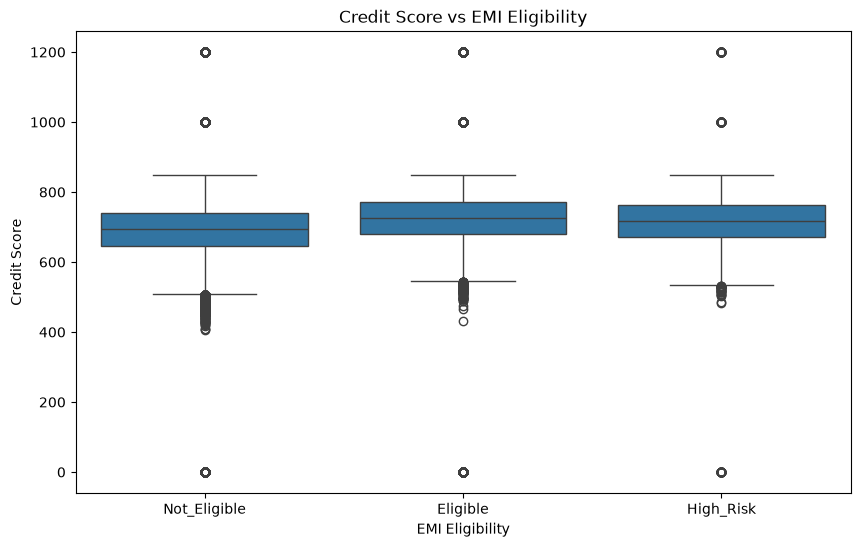

In [43]:
# Visualize credit score across EMI eligibility categories

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='emi_eligibility',
    y='credit_score'
)

plt.title('Credit Score vs EMI Eligibility')
plt.xlabel('EMI Eligibility')
plt.ylabel('Credit Score')

plt.show()